In [50]:
from google.colab import files
data = files.upload()

Saving adult_with_headers.csv to adult_with_headers (1).csv


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
data = pd.read_csv('/content/adult_with_headers.csv')

In [53]:
data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [55]:
data.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [56]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


Numerical columns in the dataset:
1. age
2. education_num
3. capital_gain
4. capital_loss
5. hours_per_week

Before scaling its important to understand the the assumptions and pre-requisites for both MinMax and Standard scaler



---
**MinMax Scaler**


1.   High sensitive to outliers
2.   Data should have a range
3.   It can accept non - normal distribution

**Standard Scaler**
1. Data should have approximate gaussian or normal distribution
2. No heavy skewness or kurtosis





age - Skewness: 0.559, Kurtosis: -0.166


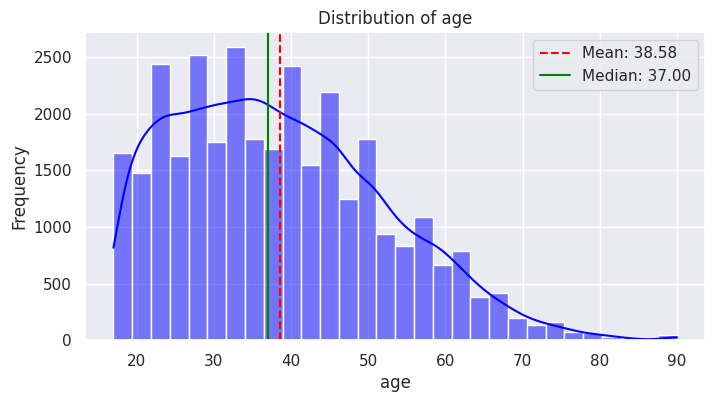

fnlwgt - Skewness: 1.447, Kurtosis: 6.218


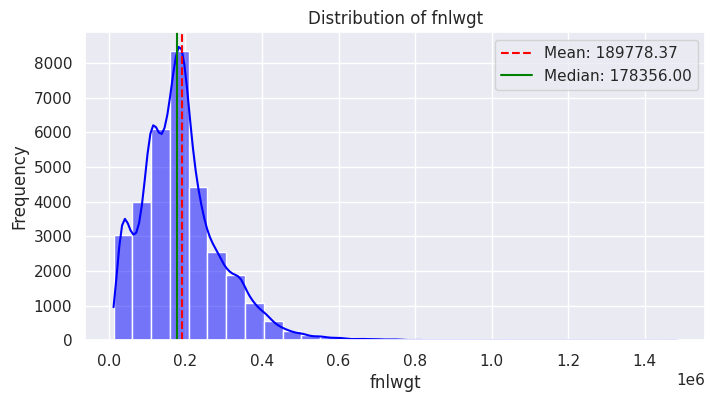

education_num - Skewness: -0.312, Kurtosis: 0.623


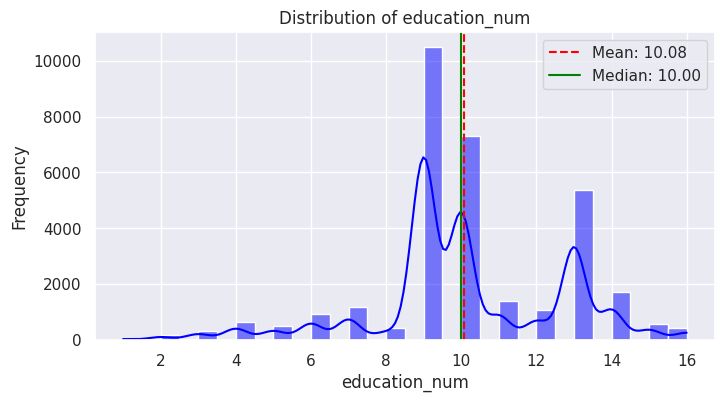

capital_gain - Skewness: 11.953, Kurtosis: 154.775


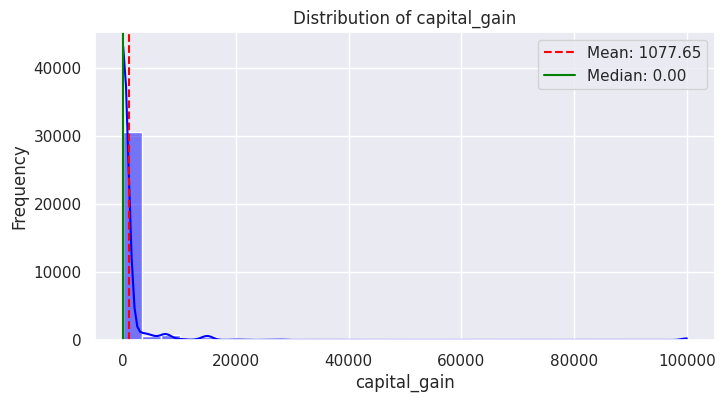

capital_loss - Skewness: 4.594, Kurtosis: 20.373


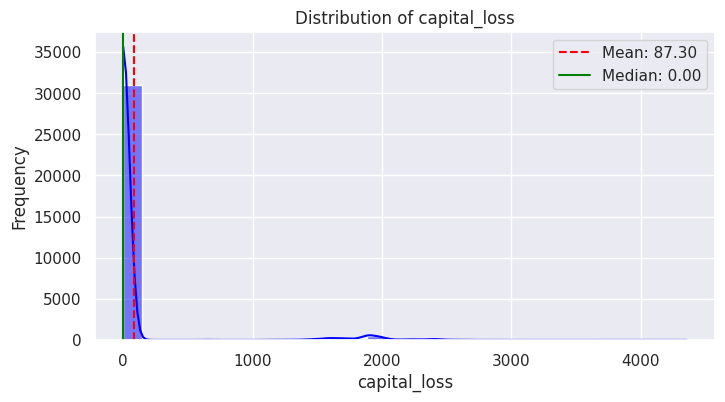

hours_per_week - Skewness: 0.228, Kurtosis: 2.916


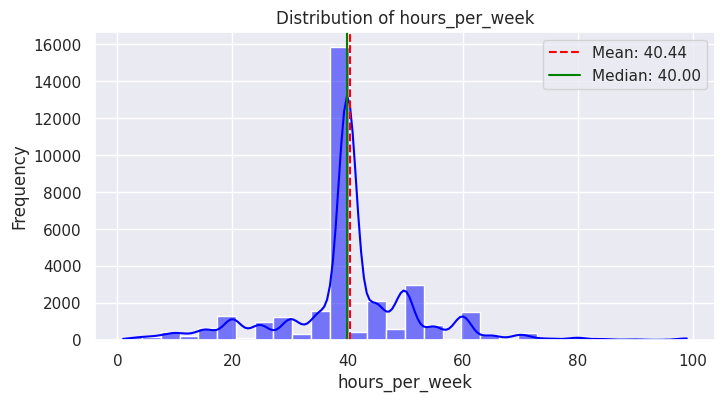

In [57]:
from scipy.stats import skew, kurtosis
sns.set_theme(style='darkgrid', palette='bright')

columns_to_plot = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

# Plot grid of histograms with KDE
for column in columns_to_plot:
    plt.figure(figsize=(8, 4))
    ax = sns.histplot(data[column], kde=True, bins=30, color='blue')

    # Add vertical lines for mean and median
    mean_val = data[column].mean()
    median_val = data[column].median()
    ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')

    # Title and legends
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.legend()

    # Print skewness and kurtosis
    print(f"{column} - Skewness: {skew(data[column].dropna()):.3f}, Kurtosis: {kurtosis(data[column].dropna()):.3f}")

    plt.show()

In [58]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

#using standard scaler for age, education_num and hour_per_week
scaler = StandardScaler()
data[['age', 'education_num', 'hours_per_week']] = scaler.fit_transform(data[['age', 'education_num', 'hours_per_week']])


In [59]:
#using MinMax scaler for capital_gain and capital_loss
scaler = MinMaxScaler()
data[['capital_gain', 'capital_loss']] = scaler.fit_transform(data[['capital_gain', 'capital_loss']])

In [60]:
data.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030671,State-gov,77516,Bachelors,1.134739,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,-0.035429,United-States,<=50K
1,0.837109,Self-emp-not-inc,83311,Bachelors,1.134739,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,-2.222153,United-States,<=50K
2,-0.042642,Private,215646,HS-grad,-0.420060,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,-0.035429,United-States,<=50K
3,1.057047,Private,234721,11th,-1.197459,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,-0.035429,United-States,<=50K
4,-0.775768,Private,338409,Bachelors,1.134739,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,-0.035429,Cuba,<=50K


In [61]:
categorical_col = 'workclass',  'education',  'marital_status', 'occupation', 'relationship', 'race', 'sex',  'native_country', 'income'

#check for number of unique values in all the categorical column
for col in categorical_col:
  print(f'{col}: {data[col].nunique()}')



workclass: 9
education: 16
marital_status: 7
occupation: 15
relationship: 6
race: 5
sex: 2
native_country: 42
income: 2


In [62]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

#encoding sex and income with one hot encoding
encoder = OneHotEncoder()
encoded_sex_income = encoder.fit_transform(data[['sex', 'income']])


# Create DataFrames from the one-hot encoded outputs
encoded_sex_income_df = pd.DataFrame(encoded_sex_income.toarray(), columns=encoder.get_feature_names_out(['sex', 'income']))


# Concatenate the one-hot encoded DataFrames with the original data DataFrame
# Drop the original 'sex' and 'income' columns before concatenation
data = data.drop(['sex', 'income'], axis=1)
data = pd.concat([data.reset_index(drop=True), encoded_sex_income_df], axis=1)

In [63]:
from sklearn.preprocessing import LabelEncoder

#ecoding 'workclass',  'education',  'marital_status', 'occupation', 'relationship', 'race',  'native_country' with label encoder
le = LabelEncoder()
columns_for_label_encoding = ['workclass',  'education',  'marital_status', 'occupation', 'relationship', 'race',  'native_country']
for col in columns_for_label_encoding:
  data[col] = le.fit_transform(data[col])

In [64]:
data.shape

(32561, 17)

One-Hot Encoding
Pros:

No Implicit Order: Does not assume any ranking between categories, making it ideal for nominal (unordered) categories (e.g., city names, product IDs).​

Model Compatibility: Works well with algorithms that expect binary inputs or that don’t infer ordinal relationships (e.g., linear regression, logistic regression, neural networks).​

Interpretability: The meaning of each binary column is clear—if the column is 1, that specific category is present.​

No Unintended Bias: Eliminates the risk of models assuming ordinal relationships between categories.​

Cons:

High Dimensionality: If there are many unique categories, one-hot encoding can create a large number of columns, leading to the "curse of dimensionality".​

Sparsity: Most values will be zeros, resulting in sparse data that may require efficient storage (sparse matrices).​

More Computation: Increased feature space means higher memory usage and computation time, especially with high-cardinality categories.​

Label Encoding
Pros:

Compactness: Transforms categories into a single column with integer values, using much less memory and computation.​

Efficiency: Works well for ordinal data where the ranked order of categories is meaningful (e.g., education level: Low, Medium, High).​

Simple to Apply: Easy to implement and revert back to original categories.​

Cons:

Implicit Ordering: Imposes an order/rank, which is misleading for nominal features without inherent order.​

Model Misinterpretation: Some algorithms (like linear or distance-based models) may misinterpret the numerical values as ordered or continuous, introducing bias.​

Less Interpretability: Integers assigned to categories don't have an obvious meaning, which could reduce transparency in communications.

In [65]:
data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,0.030671,7,77516,9,1.134739,4,1,1,4,0.02174,0.0,-0.035429,39,0.0,1.0,1.0,0.0
1,0.837109,6,83311,9,1.134739,2,4,0,4,0.00000,0.0,-2.222153,39,0.0,1.0,1.0,0.0
2,-0.042642,4,215646,11,-0.420060,0,6,1,4,0.00000,0.0,-0.035429,39,0.0,1.0,1.0,0.0
3,1.057047,4,234721,1,-1.197459,2,6,0,2,0.00000,0.0,-0.035429,39,0.0,1.0,1.0,0.0
4,-0.775768,4,338409,9,1.134739,2,10,5,2,0.00000,0.0,-0.035429,5,1.0,0.0,1.0,0.0


In [66]:
#Creating features from the data


In [67]:
# Create interaction features
data['age_x_hours'] = data['age'] * data['hours_per_week']
data['education_x_hours'] = data['education_num'] * data['hours_per_week']

display(data.head())

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,age_x_hours,education_x_hours
0,0.030671,7,77516,9,1.134739,4,1,1,4,0.02174,0.0,-0.035429,39,0.0,1.0,1.0,0.0,-0.001087,-0.040203
1,0.837109,6,83311,9,1.134739,2,4,0,4,0.00000,0.0,-2.222153,39,0.0,1.0,1.0,0.0,-1.860184,-2.521563
2,-0.042642,4,215646,11,-0.420060,0,6,1,4,0.00000,0.0,-0.035429,39,0.0,1.0,1.0,0.0,0.001511,0.014882
3,1.057047,4,234721,1,-1.197459,2,6,0,2,0.00000,0.0,-0.035429,39,0.0,1.0,1.0,0.0,-0.037451,0.042425
4,-0.775768,4,338409,9,1.134739,2,10,5,2,0.00000,0.0,-0.035429,5,1.0,0.0,1.0,0.0,0.027485,-0.040203


In [68]:
display(data['age_x_hours'].describe())

,age_x_hours
count,32561.000000
mean,0.068756
std,1.224201
min,-11.124356
25%,-0.054609
50%,0.009303
75%,0.153495
max,17.879146


Rationale:

Individually, age and hours_per_week are important predictors of income:

Older individuals may have more experience or senior positions.

People who work more hours may earn more.

However, their interaction could reveal deeper insights:

Younger individuals working long hours may still earn less (entry-level jobs).

Older individuals working fewer hours may be semi-retired or part-time.

Older individuals working more hours may indicate high-income professionals.


**Feature 2**: education_x_hours = education_num * hours_per_week
Rationale:

education_num captures qualification level.

hours_per_week captures work intensity or commitment.

Their interaction can reveal return on education depending on work effort:

Highly educated people working fewer hours may earn less.

Moderately educated people working very long hours might compensate for lower education through effort.

In [69]:
#Apply log transofrmation to capital gain
data['capital_gain'] = np.log1p(data['capital_gain'])


<Axes: xlabel='capital_gain', ylabel='Count'>

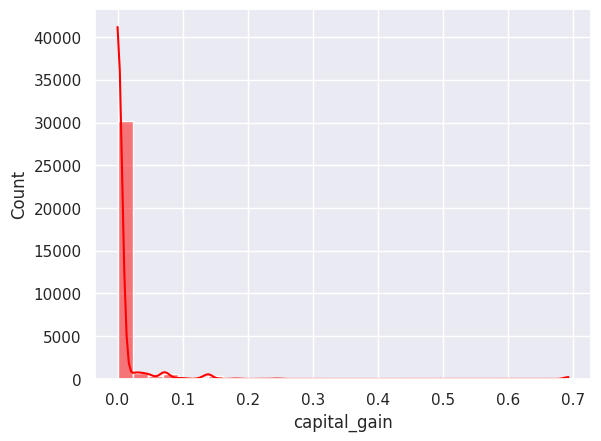

In [70]:
sns.histplot(data['capital_gain'], kde=True, bins=30, color='red')

Applied log transformation to **capital_gain** feature as it was heavily right skewed with a very large values.

Applying log transformation has benefitted in reducing the skewness, and prevents large value from dominating in the model.



In [71]:
#Isolation forest for identifying and removing outliers
from sklearn.ensemble import IsolationForest


In [72]:
#Isolation forest for identifying and removing outliers
isolation_forest = IsolationForest(contamination=0.05, random_state=42)
isolation_forest.fit(data)
outlier_predictions = isolation_forest.predict(data)



In [73]:
data['outlier'] = outlier_predictions
data['outlier'].value_counts()


,count
outlier,
1,30933
-1,1628


We have 1628 rows marked as outliers

In [74]:
#Removing outliers
data_cleaned = data[data['outlier'] == 1]
data_cleaned.shape

(30933, 20)

In [77]:
import ppscore as pps
pps.matrix(data_cleaned)

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.0,predict_itself,True,None,0.000000,1.000000,None
1,age,workclass,0.0,regression,True,mean absolute error,0.712400,0.829660,DecisionTreeRegressor()
2,age,fnlwgt,0.0,regression,True,mean absolute error,76556.178200,78057.510939,DecisionTreeRegressor()
3,age,education,0.0,regression,True,mean absolute error,2.660000,2.692437,DecisionTreeRegressor()
4,age,education_num,0.0,regression,True,mean absolute error,0.688232,0.702188,DecisionTreeRegressor()
...,...,...,...,...,...,...,...,...,...
395,outlier,income_ <=50K,0.0,regression,True,mean absolute error,0.222600,0.346155,DecisionTreeRegressor()
396,outlier,income_ >50K,0.0,regression,True,mean absolute error,0.222600,0.346155,DecisionTreeRegressor()
397,outlier,age_x_hours,0.0,regression,True,mean absolute error,0.507051,0.549139,DecisionTreeRegressor()
398,outlier,education_x_hours,0.0,regression,True,mean absolute error,0.384796,0.446029,DecisionTreeRegressor()


In [78]:
corr = data_cleaned.corr()
corr


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,age_x_hours,education_x_hours,outlier
age,1.000000,0.038936,-0.076236,0.001594,0.045136,-0.307192,-0.005150,-0.290404,0.032153,0.081600,0.043985,0.132351,0.018101,-0.111280,0.111280,-0.234102,0.234102,-0.279528,-0.018543,NaN
workclass,0.038936,1.000000,-0.021347,0.011139,0.047773,-0.058676,0.224147,-0.095522,0.046563,0.033090,0.007941,0.112452,-0.008045,-0.089760,0.089760,-0.050600,0.050600,0.006006,-0.004008,NaN
fnlwgt,-0.076236,-0.021347,1.000000,-0.030393,-0.049354,0.032722,-0.001767,0.006812,-0.026870,-0.015610,-0.010684,-0.026160,-0.058585,-0.028443,0.028443,0.015355,-0.015355,-0.006549,-0.007596,NaN
education,0.001594,0.011139,-0.030393,1.000000,0.339157,-0.030543,-0.028109,-0.006342,0.004097,0.023523,0.018905,0.051809,0.057125,0.037344,-0.037344,-0.071865,0.071865,-0.035896,-0.120842,NaN
education_num,0.045136,0.047773,-0.049354,0.339157,1.000000,-0.055689,0.106895,-0.109858,0.034562,0.107427,0.068603,0.152605,0.059138,-0.017255,0.017255,-0.320105,0.320105,-0.020359,0.072442,NaN
marital_status,-0.307192,-0.058676,0.032722,-0.030543,-0.055689,1.000000,-0.004966,0.205697,-0.073681,-0.049933,-0.034052,-0.194495,-0.030177,0.127876,-0.127876,0.196666,-0.196666,0.093623,0.036820,NaN
occupation,-0.005150,0.224147,-0.001767,-0.028109,0.106895,-0.004966,1.000000,-0.075887,0.008528,0.014359,0.016665,0.058307,-0.008769,-0.076846,0.076846,-0.074190,0.074190,0.018202,0.038314,NaN
relationship,-0.290404,-0.095522,0.006812,-0.006342,-0.109858,0.205697,-0.075887,1.000000,-0.115691,-0.099143,-0.085458,-0.268823,0.006976,0.571968,-0.571968,0.313572,-0.313572,0.131513,0.007474,NaN
race,0.032153,0.046563,-0.026870,0.004097,0.034562,-0.073681,0.008528,-0.115691,1.000000,0.033940,0.030804,0.052274,0.116608,-0.087434,0.087434,-0.096230,0.096230,-0.004136,0.025906,NaN
capital_gain,0.081600,0.033090,-0.015610,0.023523,0.107427,-0.049933,0.014359,-0.099143,0.033940,1.000000,-0.032963,0.074914,0.024703,-0.084820,0.084820,-0.233925,0.233925,0.005821,0.053841,NaN


<Axes: >

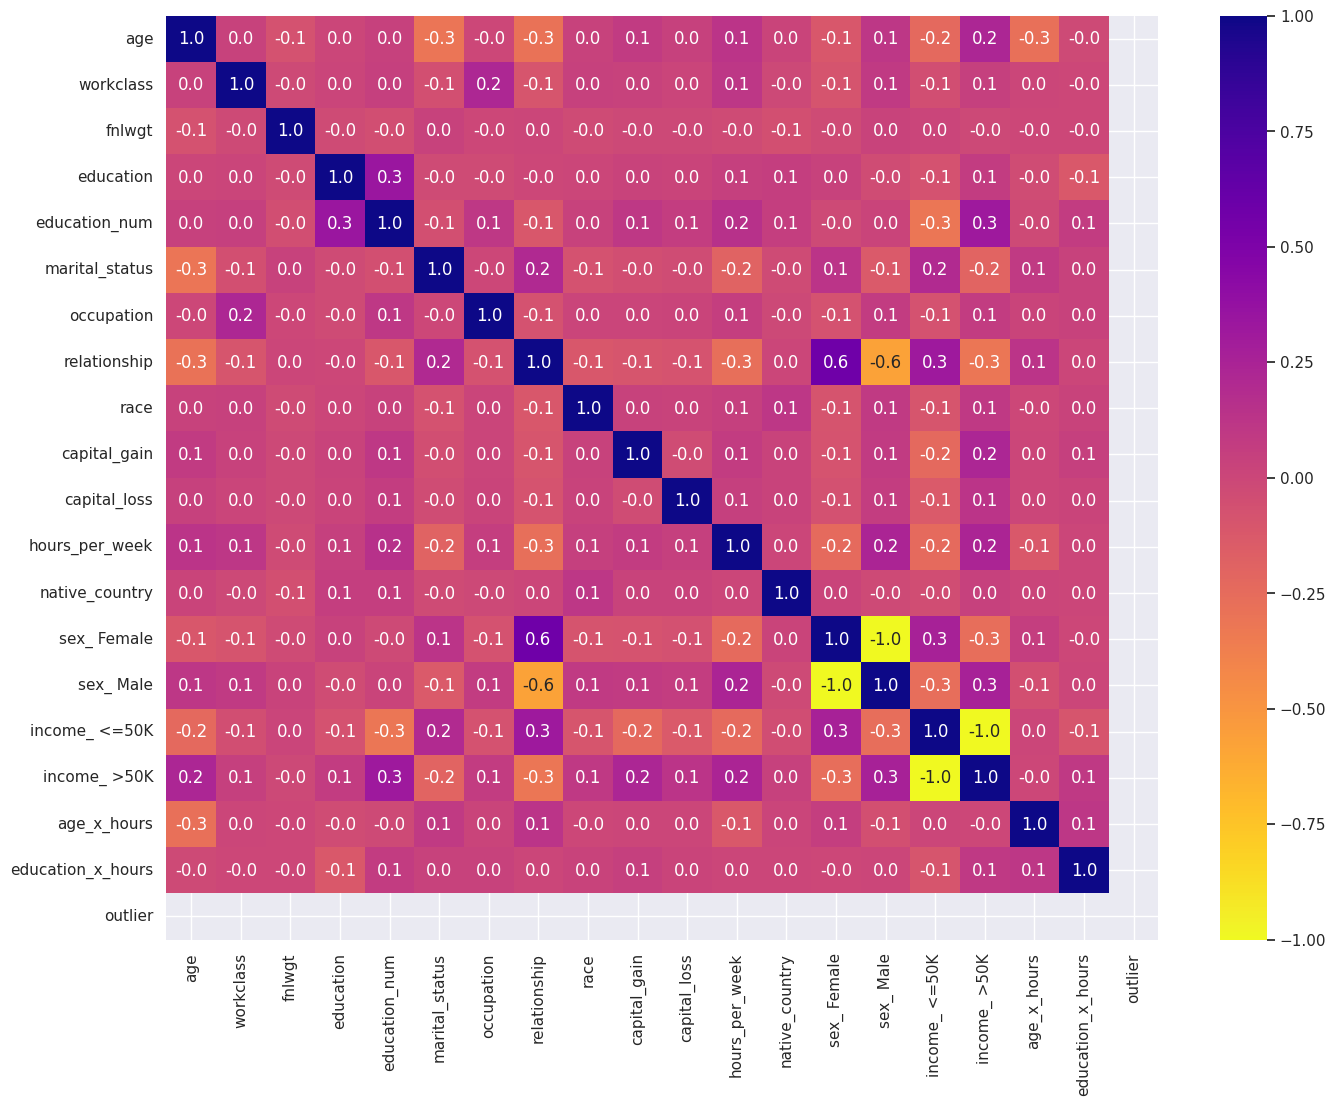

In [79]:
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True,cmap='plasma_r',fmt='.1f')


<Axes: xlabel='y', ylabel='x'>

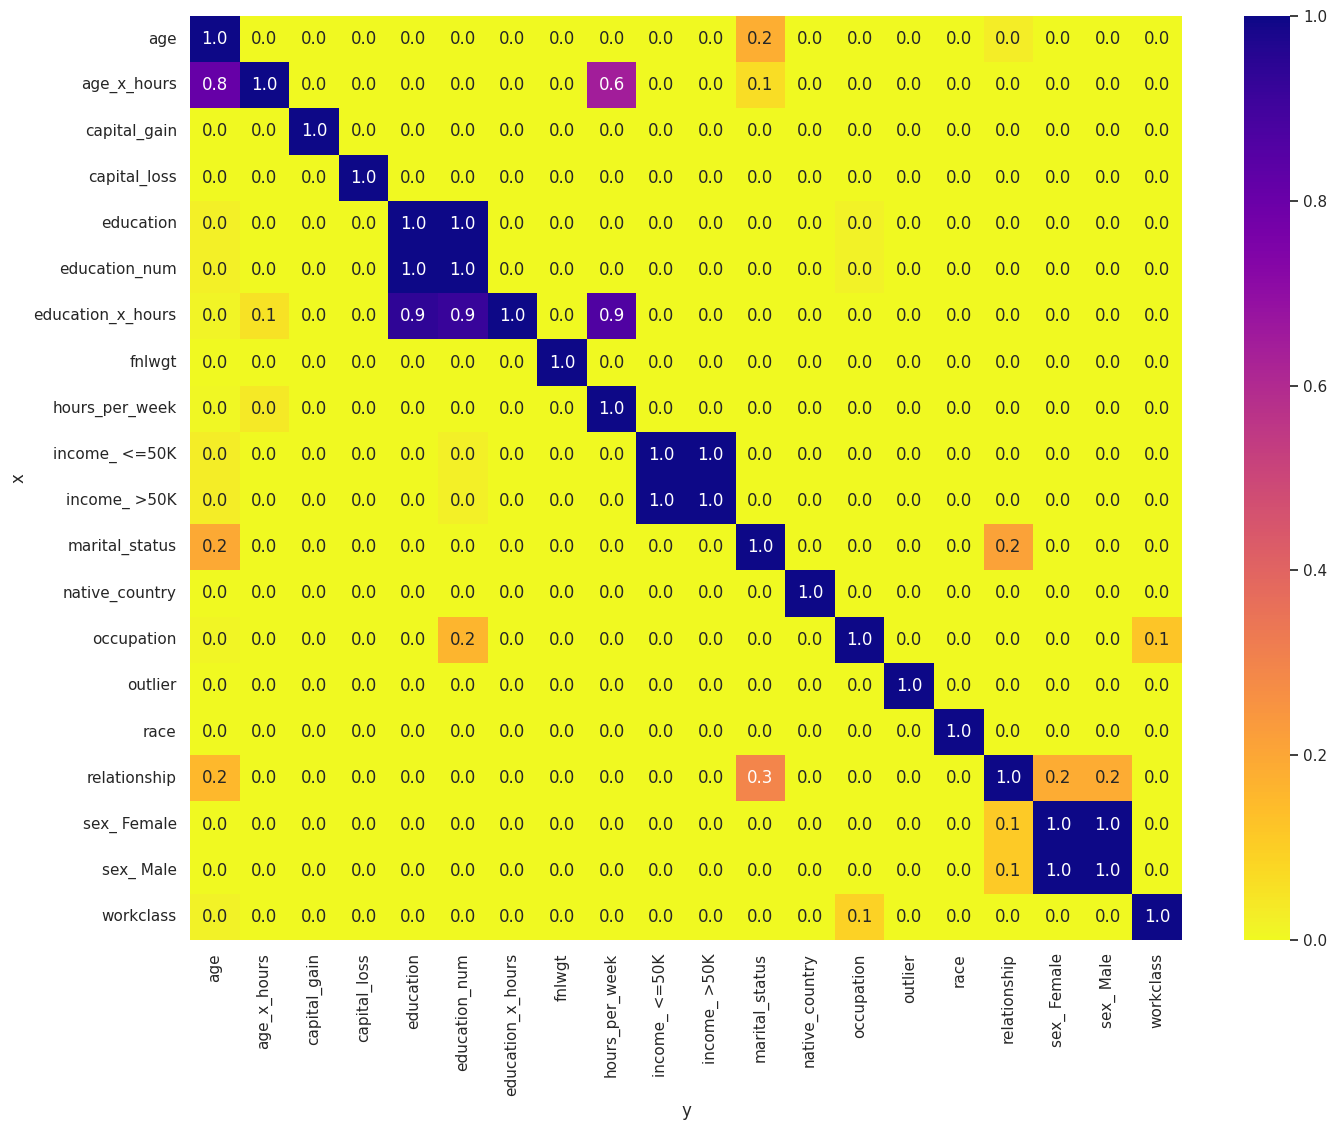

In [82]:
plt.figure(figsize=(16, 12))
pps_matrix = pps.matrix(data_cleaned)
pps_pivot = pps_matrix.pivot(index='x', columns='y', values='ppscore')
sns.heatmap(pps_pivot, annot=True,cmap='plasma_r',fmt='.1f')

Most raw pairs such as native_country, race, and fnlwgt show weak associations in both views, indicating limited predictive utility for those standalone features in this sample.​

Engineered interactions stand out in PPS: age→age_x_hours and education_num→education_x_hours register strong PPS despite only modest linear correlation, highlighting non‑linear/product effects that correlation misses.​

Redundant dummies dominate correlation but not PPS: pairs like sex_Female vs sex_Male show extreme ±1 correlation from one‑hot complementarity, whereas PPS does not over‑emphasize such artifacts and focuses on actual predictive lift from x to y.